In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))
print("TF Version:", tf.__version__)

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TF Version: 2.20.0


In [6]:
!pip install transformers torch -q

In [4]:
import os
files = os.listdir('/content/drive/MyDrive/EmoForge/text/processed')
print(files)

['train_input_ids.npy', 'test_attention_mask.npy', 'train_attention_mask.npy', 'test_labels.npy', 'dev_attention_mask.npy', 'train_labels.npy', 'dev_input_ids.npy', 'dev_labels.npy', 'test_input_ids.npy']


Using device: cuda
Loading data...
Train: (43410, 128)
Dev:   (5426, 128)
Test:  (5427, 128)
Class weights: [ 1.65724975  1.93976496 12.15966387  0.3492582   0.47968971  1.90344646
  3.07153471]
Loading DistilBERT model...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Starting DistilBERT fine-tuning...
Epoch 1/10 — Train Acc: 0.4451 | Val Acc: 0.5855 | Train Loss: 1.4931 | Val Loss: 1.1340
  ✅ Best model saved — Val Acc: 0.5855
Epoch 2/10 — Train Acc: 0.5913 | Val Acc: 0.5903 | Train Loss: 1.0484 | Val Loss: 1.0868
  ✅ Best model saved — Val Acc: 0.5903
Epoch 3/10 — Train Acc: 0.6470 | Val Acc: 0.5898 | Train Loss: 0.8485 | Val Loss: 1.1521
Epoch 4/10 — Train Acc: 0.6986 | Val Acc: 0.6113 | Train Loss: 0.6738 | Val Loss: 1.2563
  ✅ Best model saved — Val Acc: 0.6113
Epoch 5/10 — Train Acc: 0.7528 | Val Acc: 0.6185 | Train Loss: 0.5251 | Val Loss: 1.4703
  ✅ Best model saved — Val Acc: 0.6185
Epoch 6/10 — Train Acc: 0.7947 | Val Acc: 0.6273 | Train Loss: 0.4033 | Val Loss: 1.6557
  ✅ Best model saved — Val Acc: 0.6273
Epoch 7/10 — Train Acc: 0.8321 | Val Acc: 0.6117 | Train Loss: 0.3126 | Val Loss: 1.7986
Epoch 8/10 — Train Acc: 0.8560 | Val Acc: 0.6187 | Train Loss: 0.2565 | Val Loss: 2.0178
Epoch 9/10 — Train Acc: 0.8751 | Val Acc: 0.6270 | Train L

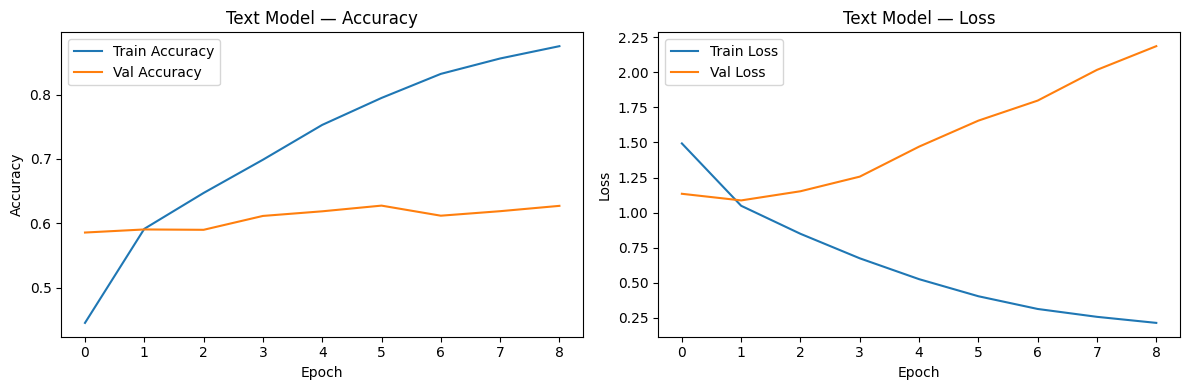

Training history plot saved!


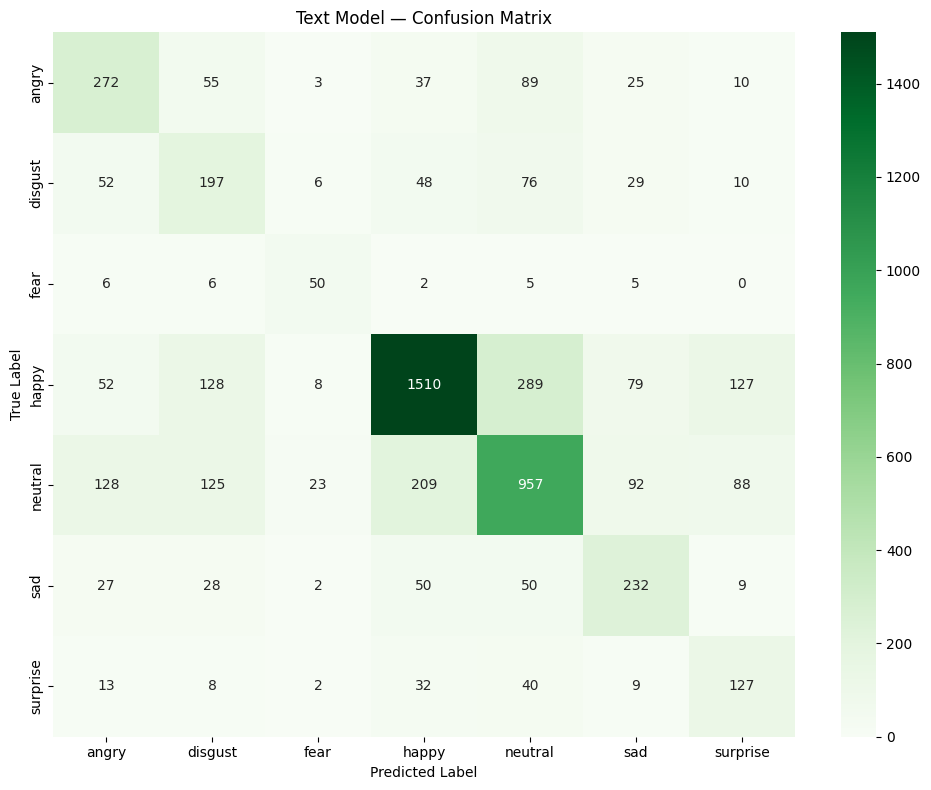

Confusion matrix saved!

Classification Report:
              precision    recall  f1-score   support

       angry       0.49      0.55      0.52       491
     disgust       0.36      0.47      0.41       418
        fear       0.53      0.68      0.60        74
       happy       0.80      0.69      0.74      2193
     neutral       0.64      0.59      0.61      1622
         sad       0.49      0.58      0.53       398
    surprise       0.34      0.55      0.42       231

    accuracy                           0.62      5427
   macro avg       0.52      0.59      0.55      5427
weighted avg       0.64      0.62      0.63      5427


Text model training complete! ✅


In [9]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
import matplotlib.pyplot as plt
import os
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# ─────────────────────────────────────────
# PATHS
# ─────────────────────────────────────────
DATA_DIR  = '/content/drive/MyDrive/EmoForge/text/processed'
MODEL_DIR = '/content/drive/MyDrive/EmoForge/models'
os.makedirs(MODEL_DIR, exist_ok=True)

# ─────────────────────────────────────────
# CHECK DEVICE
# ─────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ─────────────────────────────────────────
# LOAD DATA
# ─────────────────────────────────────────
print("Loading data...")
train_input_ids      = np.load(f'{DATA_DIR}/train_input_ids.npy')
train_attention_mask = np.load(f'{DATA_DIR}/train_attention_mask.npy')
train_labels         = np.load(f'{DATA_DIR}/train_labels.npy')

dev_input_ids        = np.load(f'{DATA_DIR}/dev_input_ids.npy')
dev_attention_mask   = np.load(f'{DATA_DIR}/dev_attention_mask.npy')
dev_labels           = np.load(f'{DATA_DIR}/dev_labels.npy')

test_input_ids       = np.load(f'{DATA_DIR}/test_input_ids.npy')
test_attention_mask  = np.load(f'{DATA_DIR}/test_attention_mask.npy')
test_labels          = np.load(f'{DATA_DIR}/test_labels.npy')

print(f"Train: {train_input_ids.shape}")
print(f"Dev:   {dev_input_ids.shape}")
print(f"Test:  {test_input_ids.shape}")

# ─────────────────────────────────────────
# EMOTIONS
# ─────────────────────────────────────────
EMOTIONS = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
NUM_CLASSES = 7

# ─────────────────────────────────────────
# CLASS WEIGHTS
# ─────────────────────────────────────────
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weight_tensor = torch.FloatTensor(class_weights).to(device)
print("Class weights:", class_weights)

# ─────────────────────────────────────────
# PYTORCH DATASET
# ─────────────────────────────────────────
class EmotionDataset(Dataset):
    def __init__(self, input_ids, attention_mask, labels):
        self.input_ids      = torch.LongTensor(input_ids)
        self.attention_mask = torch.LongTensor(attention_mask)
        self.labels         = torch.LongTensor(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.input_ids[idx],
            'attention_mask': self.attention_mask[idx],
            'labels':         self.labels[idx]
        }

BATCH_SIZE = 32

train_dataset = EmotionDataset(train_input_ids, train_attention_mask, train_labels)
dev_dataset   = EmotionDataset(dev_input_ids,   dev_attention_mask,   dev_labels)
test_dataset  = EmotionDataset(test_input_ids,  test_attention_mask,  test_labels)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
dev_loader   = DataLoader(dev_dataset,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

# ─────────────────────────────────────────
# LOAD DISTILBERT MODEL
# ─────────────────────────────────────────
print("Loading DistilBERT model...")
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=NUM_CLASSES
)
model = model.to(device)

# ─────────────────────────────────────────
# OPTIMIZER AND SCHEDULER
# ─────────────────────────────────────────
EPOCHS = 10
optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=total_steps // 10,
    num_training_steps=total_steps
)

loss_fn = torch.nn.CrossEntropyLoss(weight=class_weight_tensor)

# ─────────────────────────────────────────
# TRAINING LOOP
# ─────────────────────────────────────────
train_accs, val_accs = [], []
train_losses, val_losses = [], []
best_val_acc = 0
patience_counter = 0
PATIENCE = 3

print("Starting DistilBERT fine-tuning...")

for epoch in range(EPOCHS):
    # Training
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in train_loader:
        optimizer.zero_grad()
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = loss_fn(outputs.logits, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = outputs.logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc  = correct / total
    train_loss = total_loss / len(train_loader)

    # Validation
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for batch in dev_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = loss_fn(outputs.logits, labels)

            val_loss += loss.item()
            preds = outputs.logits.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc  = val_correct / val_total
    val_loss = val_loss / len(dev_loader)

    train_accs.append(train_acc)
    val_accs.append(val_acc)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} — Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), f'{MODEL_DIR}/text_model_best.pt')
        print(f"  ✅ Best model saved — Val Acc: {val_acc:.4f}")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

# ─────────────────────────────────────────
# EVALUATE ON TEST SET
# ─────────────────────────────────────────
print("\nLoading best model for evaluation...")
model.load_state_dict(torch.load(f'{MODEL_DIR}/text_model_best.pt'))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = outputs.logits.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = (all_preds == all_labels).mean()
print(f"\nTest Accuracy: {test_acc*100:.2f}%")

# ─────────────────────────────────────────
# PLOT TRAINING HISTORY
# ─────────────────────────────────────────
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs,   label='Val Accuracy')
plt.title('Text Model — Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses,   label='Val Loss')
plt.title('Text Model — Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/text_model_training_history.png')
plt.show()
print("Training history plot saved!")

# ─────────────────────────────────────────
# CONFUSION MATRIX
# ─────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=EMOTIONS, yticklabels=EMOTIONS)
plt.title('Text Model — Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/text_model_confusion_matrix.png')
plt.show()
print("Confusion matrix saved!")

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=EMOTIONS))

print("\nText model training complete! ✅")